In [148]:
from econml.dml import CausalForestDML
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [188]:
DISCOUNT_EXPENSE_LOW = .10
DISCOUNT_EXPENSE_HI = .25
TECH_SUPPORT_EXPENSE_LOW = .07
TECH_SUPPORT_EXPENSE_HI = .12

ADD_THRESH = 0.15  # threshold ratio for adding a promotion
REMOVE_THRESH = 0.25   # threshold ratio for removing an existing promotion from a customer

### Load data and engineer variable

In [189]:
df = pd.read_csv('../data/software_usage_promotion.csv')

df['Combined Treatment'] = (df['Discount'] *
                            df['Tech Support']).astype('category')
confounders = [
    'Size', 'Employee Count', 'PC Count', 'IT Spend', 'Major Flag',
    'Global Flag', 'Commercial Flag', 'SMC Flag'
]

In [190]:
def update_revenue(row, disc_exp, tech_exp):
    revenue = row['Revenue']
    discount = row['Discount']
    tech = row['Tech Support']

    match(discount, tech):
        case (0, 0):
            return revenue
        case (1, 0):
            return revenue * (1 - disc_exp)
        case (0, 1):
            return revenue * (1 - tech_exp)
        case (1, 1):
            return revenue * (1 - tech_exp - disc_exp)

In [191]:
df['Revenue low expense'] = df.apply(update_revenue, disc_exp=DISCOUNT_EXPENSE_LOW, tech_exp=TECH_SUPPORT_EXPENSE_LOW, axis=1)
df['Revenue hi expense'] = df.apply(update_revenue, disc_exp=DISCOUNT_EXPENSE_HI, tech_exp=TECH_SUPPORT_EXPENSE_HI, axis=1)

### Model with CausalForest

In [192]:
def make_cf():
    return CausalForestDML(
        model_y=GradientBoostingRegressor(),
        model_t=DecisionTreeClassifier(max_depth=3),
        discrete_treatment=True,
        n_estimators=100,
        max_depth=10,
        random_state=42
    )

In [193]:
cf_discount = make_cf().fit(Y=df['Revenue'],
       T=df['Discount'],
       X=df[confounders])

cf_tech = make_cf().fit(Y=df['Revenue'], T=df['Tech Support'], X=df[confounders])

cf_combined = make_cf().fit(Y=df['Revenue'], T=df['Combined Treatment'], X=df[confounders])

In [ ]:
df['cate_discount'] = cf_discount.effect(df[confounders])
df['cate_tech_support'] = cf_tech.effect(df[confounders])
df['cate_both'] = cf_combined.effect(df[confounders])

### Determine Optimal Strategy

In [194]:
def row_optimal_strategy(row):
    discount = row['Discount']
    tech = row['Tech Support']

    match (discount, tech):
        case (0, 0):  # None
            lifts = {
                'none': 0,
                'discount': row['cate_discount'],
                'tech_support': row['cate_tech_support'],
                'both': row['cate_both']
            }
        case (1, 0): # Discount
            lifts = {
                'none': -row['cate_discount'],
                'discount': 0,
                'tech_support': row['cate_tech_support'] - row['cate_discount'],
                'both': row['cate_both'] - row['cate_discount']
            }
        case (0, 1): # Tech
            lifts = {
                'none': -row['cate_tech_support'],
                'discount': row['cate_discount'] - row['cate_tech_support'],
                'tech_support': 0,
                'both': row['cate_both'] - row['cate_tech_support']
            }
        case (1, 1): # Both
            lifts = {
                'none': -row['cate_both'],
                'discount': row['cate_discount'] - row['cate_both'],
                'tech_support': row['cate_tech_support'] - row['cate_both'],
                'both': 0
            }

        case _:  # fallback
            raise ValueError("Unexpected treatment combination")

    best_action = max(lifts, key=lifts.get)
    best_lift = lifts[best_action]

    return pd.Series({'recommended_action': best_action, 'incremental_lift': best_lift})


In [10]:
df[['recommended_action', 'incremental_lift']] = df.apply(row_optimal_strategy, axis=1)

In [11]:
rec_no_treatment = df[df.incremental_lift==0]

In [12]:
rec_no_treatment.shape

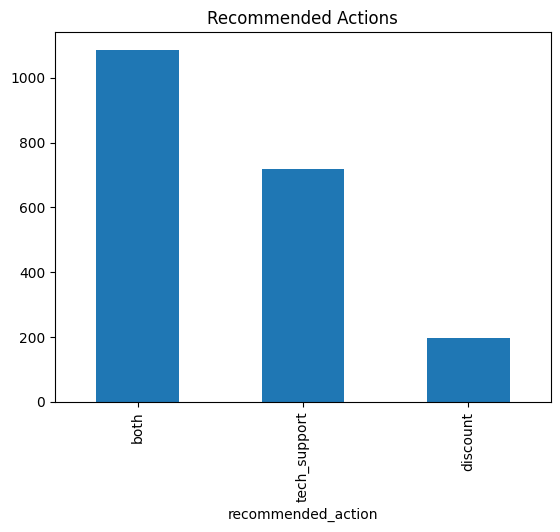

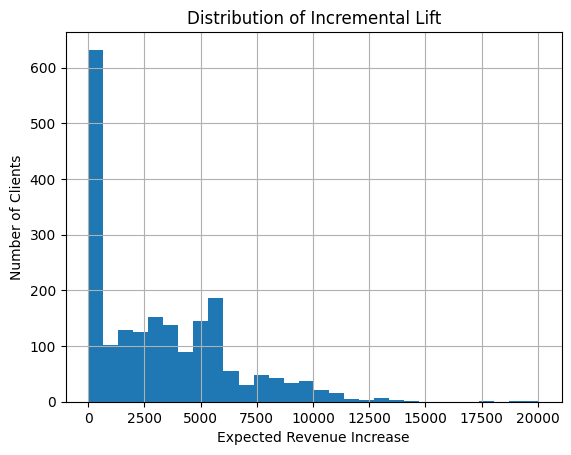

In [13]:
df['recommended_action'].value_counts().plot(kind='bar', title='Recommended Actions')
plt.show()

# Distribution of incremental lift
df['incremental_lift'].hist(bins=30)
plt.title('Distribution of Incremental Lift')
plt.xlabel('Expected Revenue Increase')
plt.ylabel('Number of Clients')
plt.show()

### Constraint-Based Recommendations

In [195]:
def make_final_recommendation(row, rev_col, add_treatment_thresh, remove_treatment_thresh):
    discount = row['Discount']
    tech_support = row['Tech Support']
    recommend = row['recommended_action']
    revenue = row[rev_col]
    lift = row['incremental_lift']

    revenue_threshold_add = (lift / revenue) > add_treatment_thresh
    revenue_threshold_remove = (lift / revenue) > remove_treatment_thresh

    match(discount, tech_support, recommend):
        case(0, 0, 'both') if revenue_threshold_add:
            return 'add both'
        case(0, 0, 'tech_support') if revenue_threshold_add:
            return 'add tech support'
        case(0, 0, 'discount') if revenue_threshold_add:
            return 'add_discount'
        case(0, 1, 'both') if revenue_threshold_add:
            return 'add discount to tech support'
        case(1, 0, 'both') if revenue_threshold_add:
            return 'add tech support to discount'
        case(0, 1, 'none') if revenue_threshold_remove:
            return 'remove tech support'
        case(1, 0, 'none') if revenue_threshold_remove:
            return 'remove discount'
        case(1, 1, 'none') if revenue_threshold_remove:
            return 'remove both'
        case(1, 1, 'tech_support') if revenue_threshold_remove:
            return 'remove discount from both'
        case(1, 1, 'discount') if revenue_threshold_remove:
            return 'remove tech support from both'
        case _:
            return 'no action'


In [196]:
def model_wrapper(inp_df, rev_col, add_treatment_thresh, remove_treatment_thresh):

    train_df, test_df = train_test_split(inp_df, test_size=0.05, random_state=42)

    disc_model = make_cf().fit(Y=train_df[rev_col],
       T=train_df['Discount'],
       X=train_df[confounders])

    tech_model = make_cf().fit(Y=train_df[rev_col], T=train_df['Tech Support'], X=train_df[confounders])

    combined_model = make_cf().fit(Y=train_df[rev_col], T=train_df['Combined Treatment'], X=train_df[confounders])

    inp_df_ = train_df.copy()

    inp_df_['cate_discount'] = disc_model.effect(inp_df_[confounders])
    inp_df_['cate_tech_support'] = tech_model.effect(inp_df_[confounders])
    inp_df_['cate_both'] = combined_model.effect(inp_df_[confounders])

    inp_df_[['recommended_action', 'incremental_lift']] = inp_df_.apply(row_optimal_strategy, axis=1)

    inp_df_['final_recommendation'] = inp_df_.apply(make_final_recommendation,
                                                    rev_col = rev_col,
                                                    add_treatment_thresh = add_treatment_thresh,
                                                    remove_treatment_thresh = remove_treatment_thresh,
                                                    axis=1)

    test_df['cate_discount'] = disc_model.effect(test_df[confounders])
    test_df['cate_tech_support'] = tech_model.effect(test_df[confounders])
    test_df['cate_both'] = combined_model.effect(test_df[confounders])

    # apply optimal strategy here is different
    test_df[['recommended_action', 'incremental_lift']] = test_df.apply(row_optimal_strategy, axis=1)

    test_df['final_recommendation'] = test_df.apply(make_final_recommendation,
                                                    rev_col = rev_col,
                                                    add_treatment_thresh = add_treatment_thresh,
                                                    remove_treatment_thresh = remove_treatment_thresh,
                                                    axis=1)

    return inp_df_, test_df

In [197]:
train_low_expense_rec, test_low_expense_rec = model_wrapper(df, 'Revenue low expense', ADD_THRESH, REMOVE_THRESH)
train_hi_expense_rec, test_hi_expense_rec = model_wrapper(df, 'Revenue hi expense', ADD_THRESH, REMOVE_THRESH)

In [198]:
train_low_exp_lift = train_low_expense_rec[train_low_expense_rec.final_recommendation!='no action'].incremental_lift.sum() / train_low_expense_rec['Revenue low expense'].sum()
train_hi_exp_lift = train_hi_expense_rec[train_hi_expense_rec.final_recommendation!='no action'].incremental_lift.sum() / train_hi_expense_rec['Revenue hi expense'].sum()

test_low_exp_lift = test_low_expense_rec[test_low_expense_rec.final_recommendation!='no action'].incremental_lift.sum() / test_low_expense_rec['Revenue low expense'].sum()
test_hi_exp_lift = test_hi_expense_rec[test_hi_expense_rec.final_recommendation!='no action'].incremental_lift.sum() / test_hi_expense_rec['Revenue hi expense'].sum()

In [199]:
pd.Series([train_low_exp_lift, train_hi_exp_lift, test_low_exp_lift, test_hi_exp_lift],
          index = ['Train low expense lift',
                     'Train hi expense lift',
                     'Test low expense lift',
                     'Test hi expense lift'])

Train low expense lift    0.107093
Train hi expense lift     0.093757
Test low expense lift     0.092413
Test hi expense lift      0.084448
dtype: float64

In [200]:
train_low_expense_rec.final_recommendation.value_counts()

final_recommendation
no action                       1338
add tech support                 335
add both                         150
add tech support to discount      63
add_discount                       8
remove discount from both          5
add discount to tech support       1
Name: count, dtype: int64

In [201]:
train_hi_expense_rec.final_recommendation.value_counts()

final_recommendation
no action                    1350
add tech support              490
remove discount from both      59
add both                        1
Name: count, dtype: int64

In [203]:
test_low_expense_rec.final_recommendation.value_counts()

final_recommendation
no action                       74
add tech support                18
add both                         5
add tech support to discount     3
Name: count, dtype: int64

In [217]:
test_low_expense_rec.query("final_recommendation!='no action'")['incremental_lift'].describe()

count      26.000000
mean     4821.779984
std      1345.349968
min      1467.645239
25%      4517.197351
50%      4839.280349
75%      5201.270782
max      7219.373565
Name: incremental_lift, dtype: float64

In [218]:
test_low_expense_rec.query("final_recommendation!='no action'").shape

<Axes: >

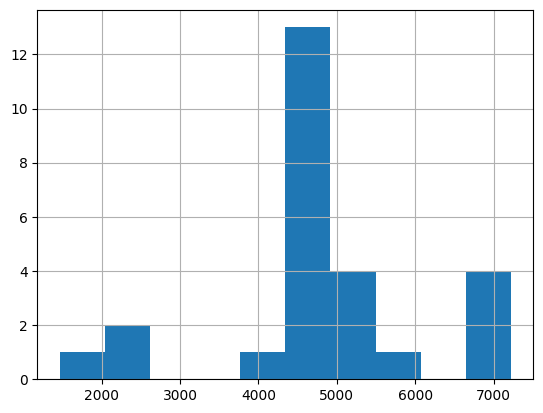

In [219]:
test_low_expense_rec.query("final_recommendation!='no action'")['incremental_lift'].hist()